# First Name: Jack
# Last Name: Kelly

# Import Libraries  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Import Data

In [7]:
bottledata = pd.read_csv('Bottle.csv', low_memory=False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# Data management 

In [22]:
sub3 = bottledata.copy()

#grab a specific height for all samples
sub3 = sub3[(sub3['R_Depth'] == 10)]

#grab required variables, dropna, set to numeric
sub3 = sub3[['Phaeop','STheta']]
sub3 = sub3.dropna(subset = ['Phaeop','STheta'])
sub3['Phaeop'] = pd.to_numeric(sub3['Phaeop'],errors='coerce')
sub3['STheta'] = pd.to_numeric(sub3['STheta'],errors='coerce')

#make it the last 100 samples for simplification
sub3 = sub3.tail(100)

print(len(sub3))
sub3.head()

100


,Phaeop,STheta
893322,0.143000,24.649830
893349,0.467000,25.218930
893353,0.526000,25.092840
893381,0.193000,25.501020
893385,0.573000,25.465040


# Linear Regression Graph

Text(0.5, 1.0, 'Sample density vs Micrograms of Phaeopigment at 10m')

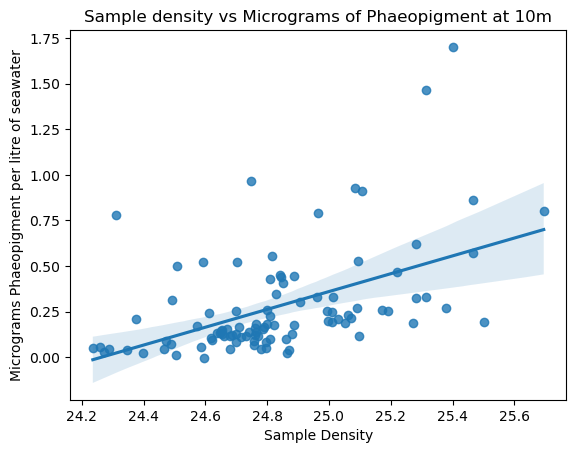

In [24]:
#display scatter plot with regression line
%matplotlib inline
plt.figure()
scat1 = sns.regplot(x="STheta", y="Phaeop", fit_reg=True, data=sub3)
plt.xlabel('Sample Density')
plt.ylabel('Micrograms Phaeopigment per litre of seawater')
plt.title('Sample density vs Micrograms of Phaeopigment at 10m')

In [28]:
#display OLS model
print ("OLS regression model for the association between Micrograms Phaeopigment and Sample density")
reg1 = smf.ols('Phaeop ~ STheta', data=sub3).fit()
print (reg1.summary())

OLS regression model for the association between Micrograms Phaeopigment and Sample density
                            OLS Regression Results                            
Dep. Variable:                 Phaeop   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     31.80
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.65e-07
Time:                        12:47:08   Log-Likelihood:                -3.7208
No. Observations:                 100   AIC:                             11.44
Df Residuals:                      98   BIC:                             16.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

Text(0.5, 1.0, 'Residual Plot')

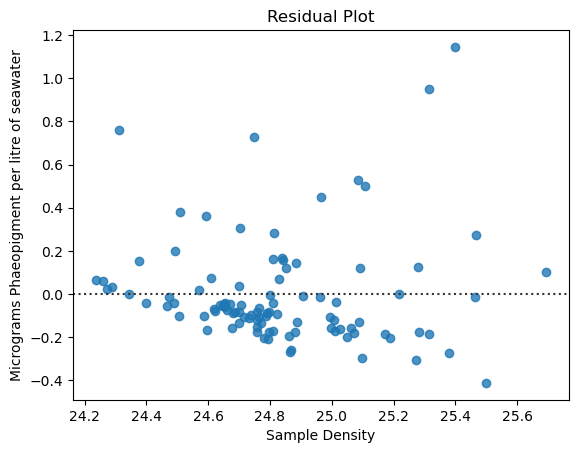

In [29]:
#Display Residual Plot
%matplotlib inline
plt.figure()
scat1 = sns.residplot(x="STheta", y="Phaeop", data=sub3)
plt.xlabel('Sample Density')
plt.ylabel('Micrograms Phaeopigment per litre of seawater')
plt.title('Residual Plot')